# **Lab 4.1 Data Augmentation with PyTorch**

In [29]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return DataLoader() and print the information about the Dataset.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>), [`ImageFolder`](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html), [`Dataloader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#:~:text=Preparing%20your%20data%20for%20training%20with%20DataLoaders)

In [30]:
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Pad(10),
        transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=45),
        transforms.CenterCrop((224, 224))
    ])

    dataset = ImageFolder(path, transform=transform)

    # Print dataset information
    print("📃Train Dataset:")
    
    # Count images per class directly from folder structure
    import os
    for class_name in dataset.classes:
        class_path = os.path.join(path, class_name)
        if os.path.exists(class_path):
            count = len([f for f in os.listdir(class_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])
            print(f"\tNumber of images in class {class_name}: {count}")
    
    print(f"\tNumber of samples: {len(dataset)}")

    data_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

    return data_loader
    ### END CODE HERE ###

Use your load_data() function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/01.png?raw=true)

</details>

📃Train Dataset:
	Number of images in class battleship: 36
	Number of images in class patrol boat: 33
	Number of images in class submarine: 28
	Number of samples: 114


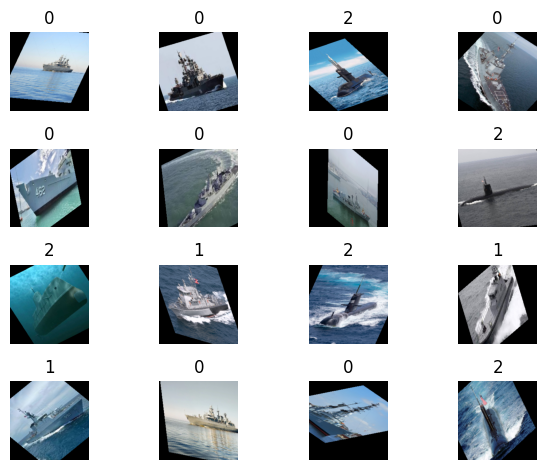

In [31]:
### START CODE HERE ###
data_loader = load_data("Ship/Train")

# Get the first batch
data_iter = iter(data_loader)
images, labels = next(data_iter)

# Display the images
fig, axes = plt.subplots(4, 4)
axes = axes.ravel()

for i in range(16):
    # Convert tensor to numpy and transpose for matplotlib
    img = images[i].permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
### END CODE HERE ###

Now, let's create your own `CustomImageDataset` that performs the augmentation as in the previous section, but also includes the methods `add_gaussian_blur()` and `add_gaussian_noise()`. **<font color="red">DO NOT</font>** use `transforms.Compose()`.

Resource : [CustomImageDataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#:~:text=.show()-,Dataset%20class,-torch.utils.data)

In [32]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_idx = {}
        
        # Load all image paths and labels
        classes = sorted(os.listdir(root_dir))
        for idx, class_name in enumerate(classes):
            if os.path.isdir(os.path.join(root_dir, class_name)):
                self.class_to_idx[class_name] = idx
                class_path = os.path.join(root_dir, class_name)
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(class_path, img_file))
                        self.labels.append(idx)
        
        self.classes = classes
    
    def __len__(self):
        return len(self.images)
    
    def add_gaussian_blur(self, image, kernel_size=5):
        """Add Gaussian blur to the image"""
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    
    def add_gaussian_noise(self, image, var=0.01):
        """Add Gaussian noise to the image"""
        # Convert to float for noise addition
        image_float = image.astype(np.float32) / 255.0
        noisy = random_noise(image_float, mode='gaussian', var=var)
        return (noisy * 255).astype(np.uint8)
    
    def augment_image(self, image):
        """Apply random augmentations to the image"""
        # Random transformations
        if random.random() > 0.5:
            # Random rotation
            angle = random.uniform(-45, 45)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h))
        
        if random.random() > 0.5:
            # Random horizontal flip
            image = cv2.flip(image, 1)
        
        if random.random() > 0.3:
            # Add Gaussian blur
            image = self.add_gaussian_blur(image)
        
        if random.random() > 0.3:
            # Add Gaussian noise
            image = self.add_gaussian_noise(image)
        
        # Random brightness and contrast
        if random.random() > 0.5:
            alpha = random.uniform(0.8, 1.2)  # Contrast
            beta = random.uniform(-20, 20)    # Brightness
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
        
        return image
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Resize image
        image = cv2.resize(image, (224, 224))
        
        # Apply augmentations
        image = self.augment_image(image)
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        return image, label
    
### END CODE HERE ###

Use your `CustomImageDataset()` function. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/02.png?raw=true)

</details>

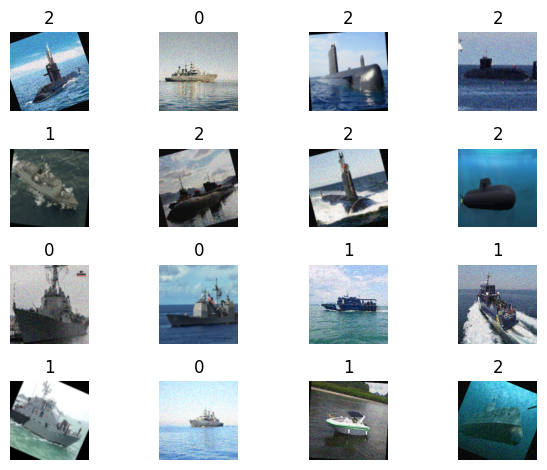

Dataset size: 97 samples
Batch shape: torch.Size([16, 3, 224, 224])
Classes: ['battleship', 'patrol boat', 'submarine']


In [ ]:
### START CODE HERE ###
dataset = CustomImageDataset("Ship/Train")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)

# Get the first batch
data_iter = iter(dataloader)
images, labels = next(data_iter)

# Display the images
fig, axes = plt.subplots(4, 4)
axes = axes.ravel()

for i in range(16):
    # Convert tensor to numpy and transpose for matplotlib
    img = images[i].permute(1, 2, 0).numpy()
    
    # Clip values to [0, 1] range for display
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img)
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Dataset size: {len(dataset)} samples")
print(f"Batch shape: {images.shape}")
### END CODE HERE ###

Questions
1. Discuss effects and benefits of fill_mode or padding_mode.
2. What would be amount of augmentation should be so that it would not effect the training performance?
3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality?
4. What would be transform parameter to simulate camera lense effect?

## **Answers**

**1. Discuss effects and benefits of fill_mode or padding_mode.**

Fill_mode or padding_mode determines how the borders of an image are handled during transformations:
- **Constant/Zero padding**: Fills with zeros or constant values - simple but may create artifacts
- **Edge/Replicate**: Replicates edge pixels - maintains color continuity
- **Reflect**: Mirrors the image at edges - creates smooth transitions
- **Wrap**: Uses opposite edge pixels - maintains periodicity
- **Benefits**: Prevents information loss during rotations, maintains image dimensions, and reduces border artifacts

**2. What would be amount of augmentation should be so that it would not effect the training performance?**

Optimal augmentation depends on:
- **Dataset size**: Smaller datasets need more augmentation (30-50% of transformations)
- **Task complexity**: Simple tasks can handle more aggressive augmentation
- **Data diversity**: Less diverse datasets benefit from more augmentation
- **General rule**: Start with 20-30% probability for each transformation and monitor validation performance
- **Too much augmentation** can make images unrecognizable and hurt performance

**3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality?**

Salt-and-pepper noise can be created by:
```python
def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy = image.copy()
    # Salt noise (white pixels)
    salt_mask = np.random.random(image.shape[:2]) < salt_prob
    noisy[salt_mask] = 255
    # Pepper noise (black pixels)
    pepper_mask = np.random.random(image.shape[:2]) < pepper_prob
    noisy[pepper_mask] = 0
    return noisy
```

**4. What would be transform parameter to simulate camera lens effect?**

Camera lens effects can be simulated using:
- **Barrel distortion**: `transforms.RandomPerspective()` with appropriate distortion parameters
- **Vignetting**: Custom transform that darkens image corners
- **Chromatic aberration**: Separate channel shifting
- **Blur effects**: `transforms.GaussianBlur()` for depth of field
- **Lens distortion**: Using `cv2.getOptimalNewCameraMatrix()` with distortion coefficients

Example:
```python
transforms.RandomPerspective(distortion_scale=0.2, p=0.5)  # Lens distortion
transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))   # Depth of field
```